# Video Game Sales
##### Ryan Hastings - 100894215
Everyone that plays video games has preferences, whether it be genre, publisher, year of release or platform. These can drastically affect how well a game sells, with different games appealing to different audiences. General interest in video games has also fluctuated over time, which could have had some interesting impacts on game sales from each publisher. Some publishers are more popular than others, some genres are more popular than others, and some platforms are more popular than others. However, platforms and publishers typically go hand-in-hand so they are basically the same thing. In this assignment I will be looking for any links between years of release and sales numbers, as well as analyzing the relationships between video game publishers, genres and their sales numbers with a focus on Nintendo's continued success in the video game industry.

# Methods
### Data Collection

In [1713]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1714]:
# Load dataset
games = pd.read_csv("video_games_sales.csv")

### Data Cleaning
This dataset had 307 instances of rows with NaN values, which were removed to make the exploratory analyses more accurate.

In [1715]:
# Delete all rows with NaN values
games = games.dropna(axis = 0)

The "rank" column and the subcategories of sales were unnecessary so they were removed. Also, due to the sheer amount of publishers we will only examine the top 5 in sales so we will have to remove all rows that do not contain those publishers.

In [1716]:
# Delete all specified columns and rows
games = games.drop(["rank", "na_sales", "eu_sales", "jp_sales", "other_sales"], axis = 1)
games = games[(games["publisher"] == "Nintendo") | (games["publisher"] == "Electronic Arts") | 
              (games["publisher"] == "Activision") | (games["publisher"] == "Sony Computer Entertainment") |
              (games["publisher"] == "Ubisoft")]

Renamed the "global_sales" columns to make it easier to understand.

In [1717]:
# Rename sales column
games.columns = ["name", "platform", "year", "genre", "publisher", "sales (millions)"]

# Analyses

### Distributions
The figure below displays the distribution of release years for all games in the dataset. As we can see, the video game industry was at its peak saturation between 2005 and 2010, with less and less games being made in recent years.

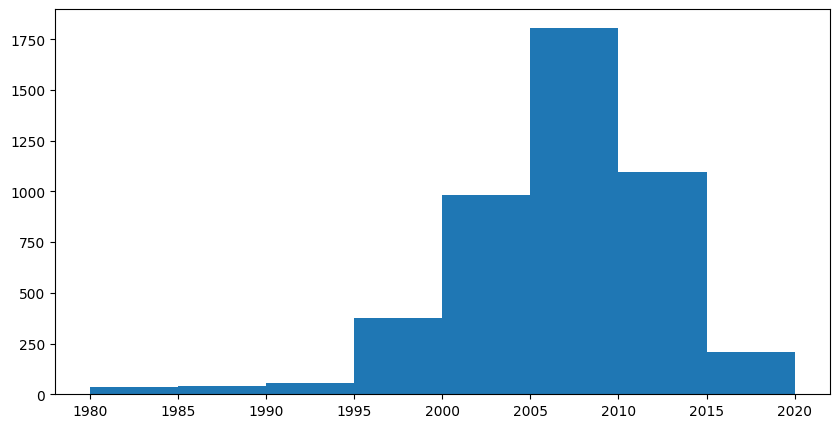

In [1718]:
# Release year distribution
genre_hist = games.year.hist(bins = 8, figsize = (10, 5), grid = False)

The minimum, maximum, and mean years listed below indicate that while game sales have dropped drastically recently, they peaked around 2006 which is closer to the present than when video games first started taking off in the 1980's. Overall video games are still incredibly popular compared to the pre-2000's.

In [1719]:
# Descriptive statistics of years of release
year_info = games.year.describe()
print(f"Mean year: {round(year_info['mean'])}")
print(f"Min year: {round(year_info['min'])}")
print(f"Max year: {round(year_info['max'])}")

Mean year: 2006
Min year: 1980
Max year: 2020


### Total Sales per Publisher and Genre
Due to the sheer amount of publishers on this dataset, and for the sake of simplicity, we will only be looking at the top 5 publishers.

In [1720]:
# Grouped sum operation with sorted values in descending order
grouped_publishers = games["sales (millions)"].groupby(games["publisher"]).sum().to_frame().sort_values(by = "sales (millions)", ascending = False)
grouped_publishers.iloc[:5]

,sales (millions)
publisher,
Nintendo,1784.43
Electronic Arts,1093.39
Activision,721.41
Sony Computer Entertainment,607.28
Ubisoft,473.54


Based on these numbers we can see that Nintendo is far and away the most popular video game publisher among consumers with almost 1.8 billion game copies sold across all of their platforms, nearly 700 million ahead of Electronic Arts (EA) in second. Below is a visual representation of the above table to emphasize the disparity between Nintendo and the rest of the publishers.

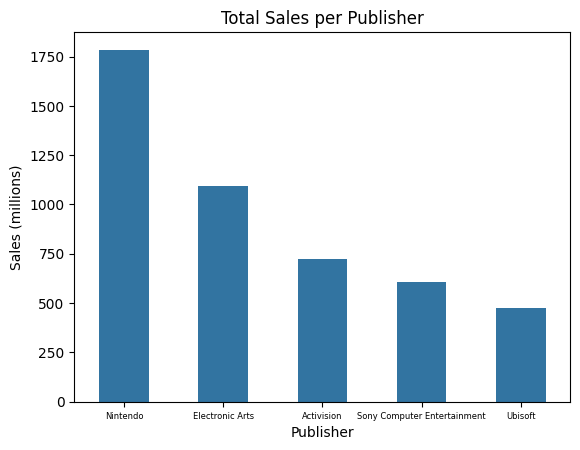

In [1721]:
publisher_bar = sns.barplot(data = grouped_publishers.iloc[:5], x = "publisher", y = "sales (millions)", width = 0.5)
publisher_bar.set_xlabel("Publisher")
publisher_bar.set_ylabel("Sales (millions)")
publisher_bar.set_title("Total Sales per Publisher")
plt.tick_params(axis = "x", labelsize = 6)

But is this simply a case of Nintendo being more popular, or is there a deeper reason for this disparity? Below is a breakdown of sales for each genre for each of the top 5 publishers.

In [1722]:
# Dropping unnecessary columns and grouping required columns
grouped_pub_genre = games.drop(["name", "platform", "year"], axis = 1)
grouped_pub_genre = grouped_pub_genre["sales (millions)"].groupby([grouped_pub_genre["publisher"], grouped_pub_genre["genre"]]).sum().unstack()

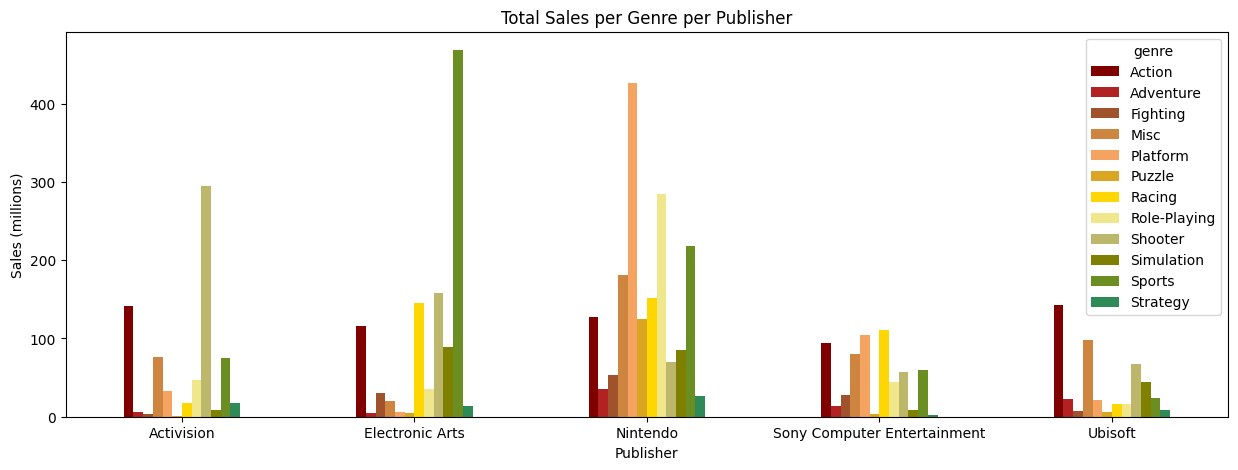

In [1723]:
# Using grouped dataframe to plot total sales per genre per publisher
pub_genre_barplot = grouped_pub_genre.plot.bar(figsize = (15, 5), 
                                               color = ["maroon", "firebrick", "sienna", "peru", "sandybrown", 
                                                        "goldenrod", "gold", "khaki", "darkkhaki", "olive", "olivedrab", "seagreen"], 
                                               title = "Total Sales per Genre per Publisher")
plt.xlabel("Publisher")
plt.ylabel("Sales (millions)")
plt.xticks(rotation = 0)
plt.show(pub_genre_barplot)

This graph shows us that while Nintendo has one main genre, they have not completely forgotten about any genres, unlike other publishers. However, Nintendo has also been around for significantly longer than most publishers and has been a top competitor in the market for all that time. The figure below demonstrates the dominance of Nintendo in the early years.

### Total Sales per Year per Publisher

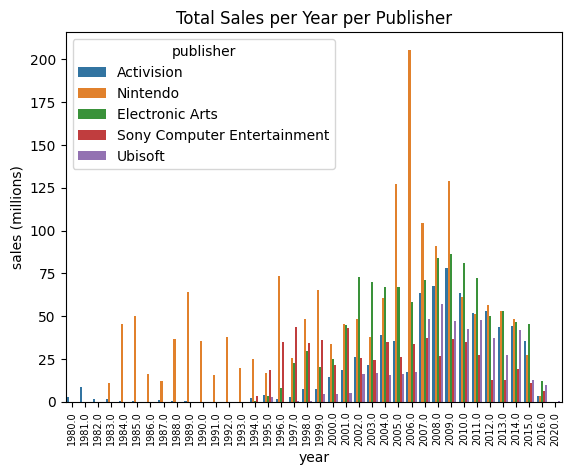

In [1724]:
grouped_years = games["sales (millions)"].groupby([games["year"], games["publisher"]]).sum().to_frame()
years_barplot = sns.barplot(data = grouped_years, x = "year", y = "sales (millions)", hue = "publisher")
years_barplot.set_title("Total Sales per Year per Publisher")
plt.tick_params(axis = "x", labelsize = 7, rotation = 90)

This definitely skewed Nintendo's total sales numbers, but even in the peak years Nintendo's sales numbers were astronomical, especially in 2006 which demonstrates the benefit of building a solid reputation.

# Discussion
In this assignment, I used video game publishers, genres, years of release, and sales numbers to determine why some publishers are more popular than others, specifically Nintendo. Nintendo has been popular for much longer than any other publisher, inflating their total sales numbers and allowing them time to build a reputation before everyone else entered the industry. However, this is not the only reason for Nintendo's continued success. Most of these publishers appear to have a standout "specialty" genre, including Nintendo, but what Nintendo has that the other publishers do not is a broader range. As we have seen, Nintendo has much better coverage over all genres than other publishers, with no genre that is completely forgotten about, unlike, for example, Activision with the puzzle genre. This means Nintendo games will appeal to a significantly bigger audience. What we can take away from this is that in order for video game publishers to maximize their sales, they should be dabbling in every genre to widen their audience and gain new customers. They should also do their best to ensure game quality to gain a good reputation, as that will allow them to maintain high amounts of sales over many years.

# References
1. Source data - https://www.kaggle.com/datasets/ulrikthygepedersen/video-games-sales
2. Pandas for data manipulation
3. Seaborn for data viz
4. Matplotlib for data viz